In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

from scipy import stats
from scipy.stats.mstats import winsorize

from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, OrdinalEncoder
from sklearn.preprocessing import PowerTransformer
from sklearn.compose import ColumnTransformer


## Loading Dataset : ( HR Attrition Dataset )

In [3]:
Original_Data = pd.read_csv("HR_Attrition.csv")

df = Original_Data.copy()

df.head()

,employee_id,age,gender,department,salary_usd,years_experience,satisfaction_score,performance_rating,overtime,remote_work,num_projects,training_hours,education_level,attrition
0,EMP00000,35.0,Female,Engineering,12355.71,19.0,3.35,High,No,On-site,7.0,40.0,Bachelor's,1
1,EMP00001,61.0,Female,Sales,54075.72,28.0,3.22,Medium,no,On-site,7.0,54.0,PhD,0
2,EMP00002,57.0,Male,Finance,48552.03,22.0,1.88,Low,Yes,Full Remote,9.0,38.0,High School,0
3,EMP00003,51.0,Female,NaN,51349.59,35.0,1.33,Medium,No,Full Remote,2.0,32.0,Bachelor's,0
4,EMP00004,53.0,Male,engineering,96251.17,0.0,1.19,Excellent,no,Hybrid,8.0,3.0,Master's,1


## Basic Info :

In [4]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5500 entries, 0 to 5499
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   employee_id         5500 non-null   object 
 1   age                 5420 non-null   float64
 2   gender              5333 non-null   object 
 3   department          5218 non-null   object 
 4   salary_usd          5440 non-null   float64
 5   years_experience    5410 non-null   float64
 6   satisfaction_score  5401 non-null   float64
 7   performance_rating  5191 non-null   object 
 8   overtime            4982 non-null   object 
 9   remote_work         5211 non-null   object 
 10  num_projects        5430 non-null   float64
 11  training_hours      5440 non-null   float64
 12  education_level     5220 non-null   object 
 13  attrition           5500 non-null   int64  
dtypes: float64(6), int64(1), object(7)
memory usage: 601.7+ KB


,age,salary_usd,years_experience,satisfaction_score,num_projects,training_hours,attrition
count,5420.000000,5440.000000,5410.000000,5401.000000,5430.000000,5440.000000,5500.000000
mean,42.894649,64441.178305,19.348244,2.980644,5.018232,49.391728,0.159273
std,12.351744,20280.189380,11.655750,1.173453,2.589890,28.644560,0.365963
min,22.000000,0.000000,0.000000,-1.000000,1.000000,0.000000,0.000000
25%,32.000000,50926.415000,9.000000,1.990000,3.000000,26.000000,0.000000
50%,43.000000,64768.325000,19.000000,3.000000,5.000000,49.000000,0.000000
75%,53.000000,78576.407500,30.000000,3.970000,7.000000,74.000000,0.000000
max,64.000000,138038.850000,39.000000,5.000000,9.000000,99.000000,1.000000


## Missing Value Identification and Dropping Unnecessary Features :

In [5]:
missing_count = df.isnull().sum()
missing_percent = (missing_count/len(df))*100

missing_df = pd.DataFrame({
    'Missing Count': missing_count,
    'Percentage(%)':missing_percent 
})

missing_df

,Missing Count,Percentage(%)
employee_id,0,0.000000
age,80,1.454545
gender,167,3.036364
department,282,5.127273
salary_usd,60,1.090909
years_experience,90,1.636364
satisfaction_score,99,1.800000
performance_rating,309,5.618182
overtime,518,9.418182
remote_work,289,5.254545


In [6]:
df = df.drop(columns=['employee_id'])

In [7]:
df.dtypes

age                   float64
gender                 object
department             object
salary_usd            float64
years_experience      float64
satisfaction_score    float64
performance_rating     object
overtime               object
remote_work            object
num_projects          float64
training_hours        float64
education_level        object
attrition               int64
dtype: object

## Checking Distribution : (Missing Numerical Feature Only)

In [8]:
Missing_num = df[['age' , 'salary_usd' , 'years_experience', 'satisfaction_score',
                'num_projects','training_hours']]

Missing_cat = df[['gender' , 'department' , 'remote_work' , 'education_level','performance_rating','overtime']]

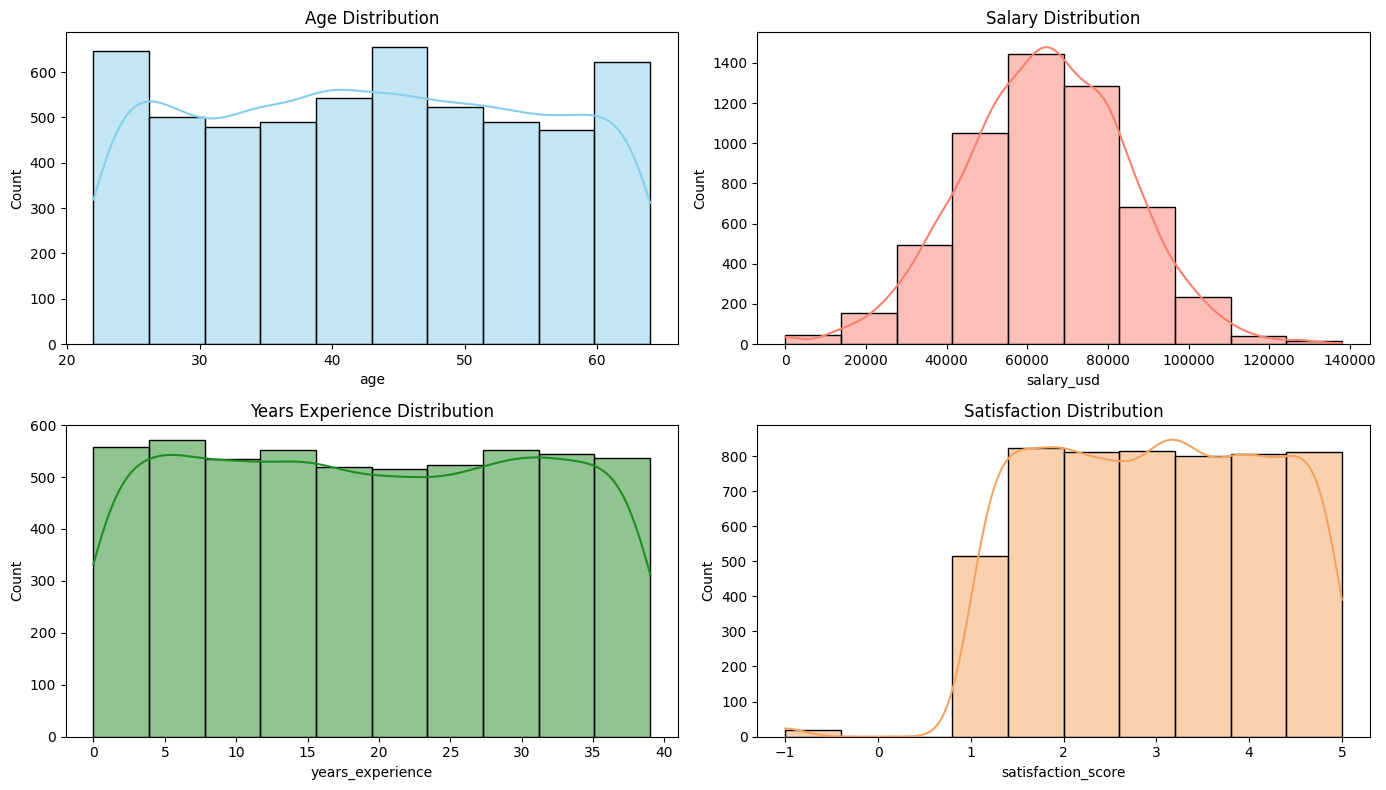

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

sns.histplot(df['age'], bins=10, kde=True, ax=axes[0,0], color='skyblue')
axes[0,0].set_title('Age Distribution')

sns.histplot(df['salary_usd'], bins=10, kde=True, ax=axes[0,1], color='salmon')
axes[0,1].set_title('Salary Distribution')

sns.histplot(df['years_experience'], bins=10, kde=True, ax=axes[1,0], color='forestgreen')
axes[1,0].set_title('Years Experience Distribution')

sns.histplot(df['satisfaction_score'], bins=10, kde=True, ax=axes[1,1], color='sandybrown')
axes[1,1].set_title('Satisfaction Distribution')

plt.tight_layout()
plt.show()

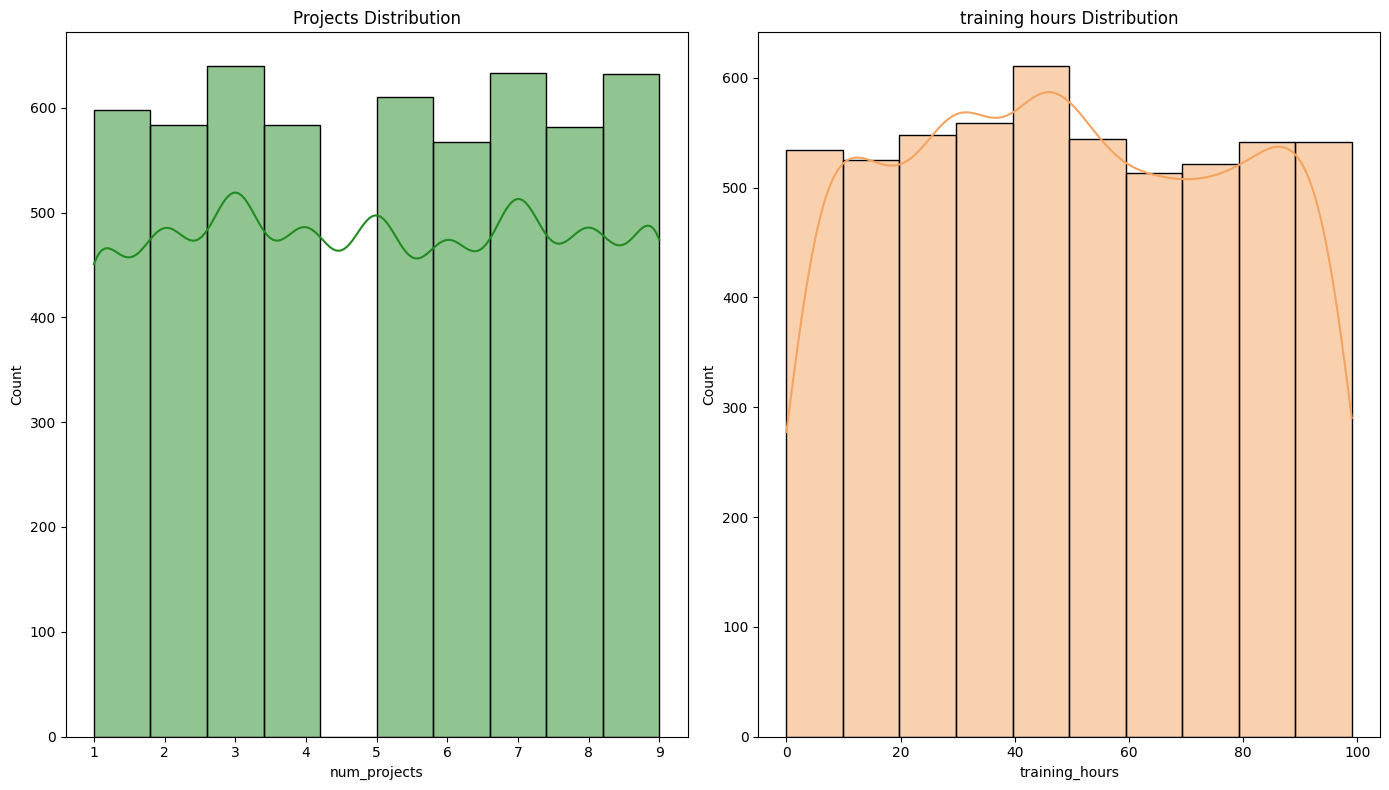

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 8))

sns.histplot(df['num_projects'], bins=10, kde=True, ax=axes[0], color='forestgreen')
axes[0].set_title('Projects Distribution')

sns.histplot(df['training_hours'], bins=10, kde=True, ax=axes[1], color='sandybrown')
axes[1].set_title('training hours Distribution')

plt.tight_layout()
plt.show()

## Missing Value Imputation :

In [11]:
Imputing_num_cols = SimpleImputer(strategy= 'mean')
df['age'] = Imputing_num_cols.fit_transform(df[['age']])
df['salary_usd'] = Imputing_num_cols.fit_transform(df[['salary_usd']])
df['years_experience'] = Imputing_num_cols.fit_transform(df[['years_experience']])
df['satisfaction_score'] = Imputing_num_cols.fit_transform(df[['satisfaction_score']])
df['num_projects'] = Imputing_num_cols.fit_transform(df[['num_projects']])
df['training_hours'] = Imputing_num_cols.fit_transform(df[['training_hours']])

In [12]:
def random_impute(col):

    values = col.dropna().values
    
    return col.apply(lambda x: np.random.choice(values) if pd.isna(x) else x)

df['gender'] = random_impute(df['gender'])
df['department'] = random_impute(df['department'])
df['remote_work'] = random_impute(df['remote_work'])
df['education_level'] = random_impute(df['education_level'])
df['performance_rating'] = random_impute(df['performance_rating'])
df['overtime'] = random_impute(df['overtime'])


In [13]:
df.isnull().sum()

age                   0
gender                0
department            0
salary_usd            0
years_experience      0
satisfaction_score    0
performance_rating    0
overtime              0
remote_work           0
num_projects          0
training_hours        0
education_level       0
attrition             0
dtype: int64

## Re-Checking Distribution :

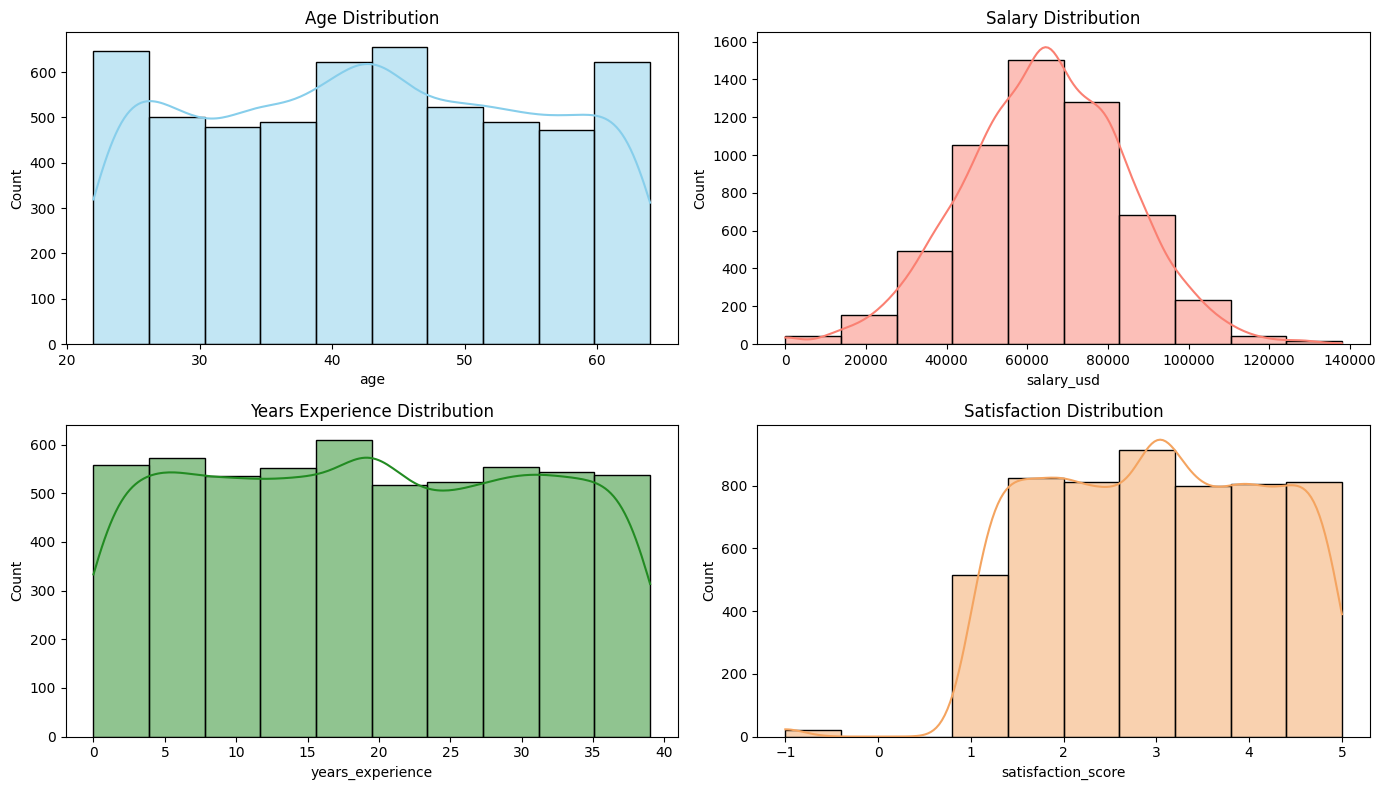

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

sns.histplot(df['age'], bins=10, kde=True, ax=axes[0,0], color='skyblue')
axes[0,0].set_title('Age Distribution')

sns.histplot(df['salary_usd'], bins=10, kde=True, ax=axes[0,1], color='salmon')
axes[0,1].set_title('Salary Distribution')

sns.histplot(df['years_experience'], bins=10, kde=True, ax=axes[1,0], color='forestgreen')
axes[1,0].set_title('Years Experience Distribution')

sns.histplot(df['satisfaction_score'], bins=10, kde=True, ax=axes[1,1], color='sandybrown')
axes[1,1].set_title('Satisfaction Distribution')

plt.tight_layout()
plt.show()

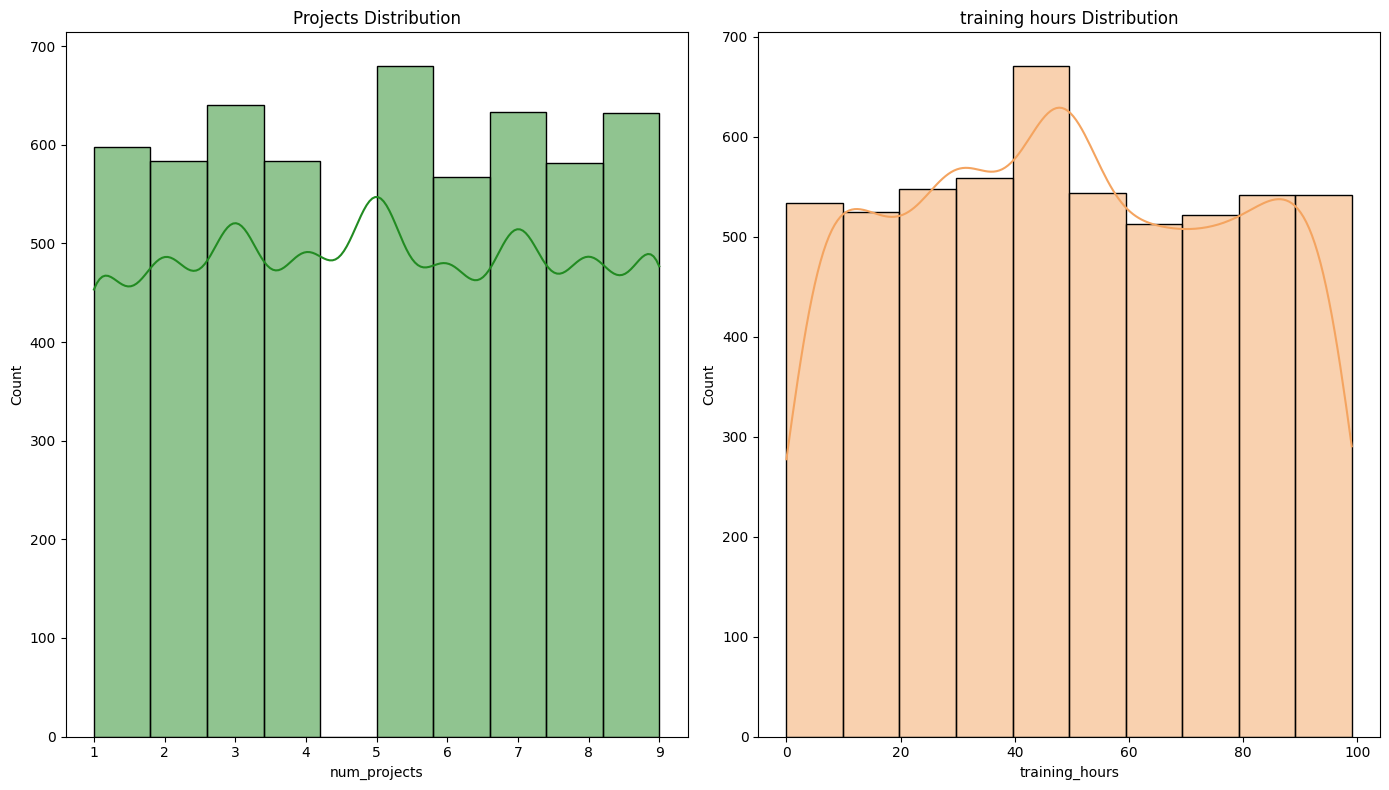

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 8))

sns.histplot(df['num_projects'], bins=10, kde=True, ax=axes[0], color='forestgreen')
axes[0].set_title('Projects Distribution')

sns.histplot(df['training_hours'], bins=10, kde=True, ax=axes[1], color='sandybrown')
axes[1].set_title('training hours Distribution')

plt.tight_layout()
plt.show()

In [16]:
df

,age,gender,department,salary_usd,years_experience,satisfaction_score,performance_rating,overtime,remote_work,num_projects,training_hours,education_level,attrition
0,35.0,Female,Engineering,12355.71,19.0,3.35,High,No,On-site,7.0,40.0,Bachelor's,1
1,61.0,Female,Sales,54075.72,28.0,3.22,Medium,no,On-site,7.0,54.0,PhD,0
2,57.0,Male,Finance,48552.03,22.0,1.88,Low,Yes,Full Remote,9.0,38.0,High School,0
3,51.0,Female,SALES,51349.59,35.0,1.33,Medium,No,Full Remote,2.0,32.0,Bachelor's,0
4,53.0,Male,engineering,96251.17,0.0,1.19,Excellent,no,Hybrid,8.0,3.0,Master's,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5495,61.0,Female,Finance,49062.14,22.0,3.19,High,no,On-site,6.0,43.0,PhD,0
5496,33.0,Non-binary,SALES,74248.33,4.0,3.25,High,yes,Hybrid,7.0,88.0,Bachelor's,0
5497,61.0,Non-binary,Finance,55771.73,28.0,4.20,Excellent,Yes,Hybrid,3.0,37.0,PhD,0
5498,27.0,Female,Sales,42080.32,35.0,3.43,High,No,On-site,9.0,74.0,Bachelor's,0


## Feature Engineering , Outlier Handling & Encoding :

In [17]:
df["department"] = df["department"].str.lower()
df["overtime"] = df["overtime"].str.lower()

In [18]:
education_order = {
    "High School": 1,
    "Associate": 2,
    "Bachelor's": 3,
    "Master's": 4,
    "PhD": 5
}

df["education_level"] = df["education_level"].map(education_order)

In [19]:
ordinal_encoder = OrdinalEncoder(
    categories=[['Low','Medium','High','Excellent']]
)

df['performance_rating'] = ordinal_encoder.fit_transform(df[['performance_rating']])

In [20]:
df.head()

,age,gender,department,salary_usd,years_experience,satisfaction_score,performance_rating,overtime,remote_work,num_projects,training_hours,education_level,attrition
0,35.0,Female,engineering,12355.71,19.0,3.35,2.0,no,On-site,7.0,40.0,3,1
1,61.0,Female,sales,54075.72,28.0,3.22,1.0,no,On-site,7.0,54.0,5,0
2,57.0,Male,finance,48552.03,22.0,1.88,0.0,yes,Full Remote,9.0,38.0,1,0
3,51.0,Female,sales,51349.59,35.0,1.33,1.0,no,Full Remote,2.0,32.0,3,0
4,53.0,Male,engineering,96251.17,0.0,1.19,3.0,no,Hybrid,8.0,3.0,4,1


In [21]:
onehot_cols = ["gender","department", "overtime", "remote_work"]

onehot_encoder = OneHotEncoder(drop='first',  sparse_output=False)

encoded_array = onehot_encoder.fit_transform(df[onehot_cols])

encoded_df = pd.DataFrame(
    encoded_array,
    columns=onehot_encoder.get_feature_names_out(onehot_cols),
    index=df.index
)

df = df.drop(columns=onehot_cols)
df = pd.concat([df, encoded_df], axis=1)

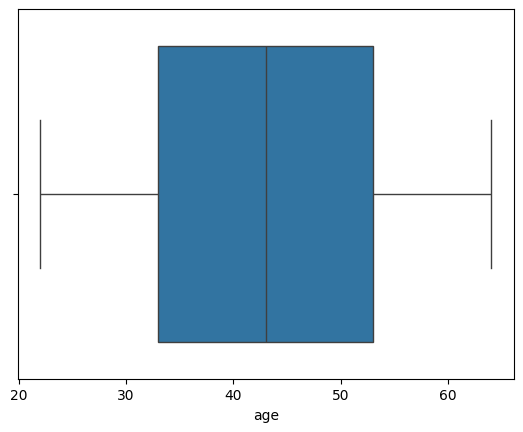

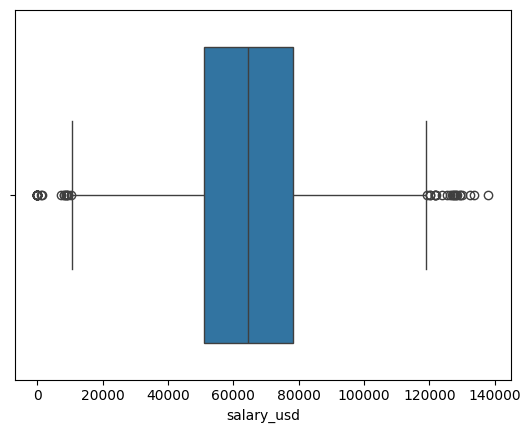

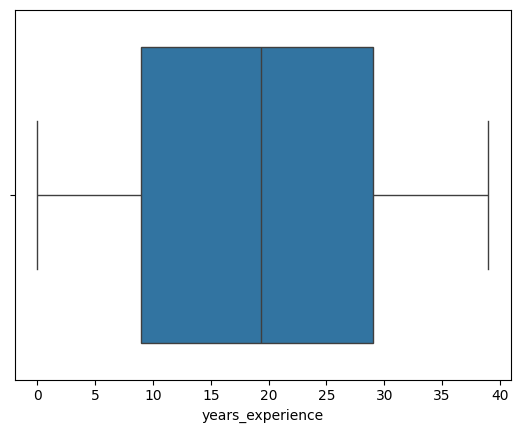

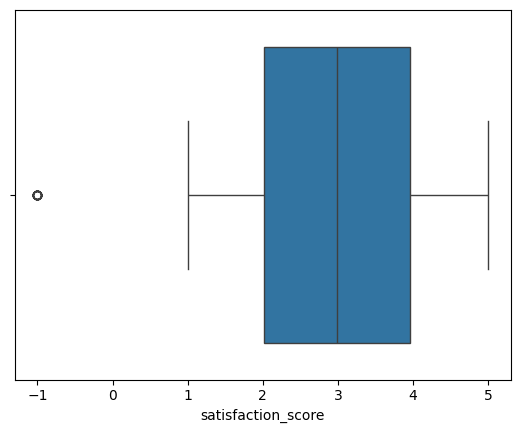

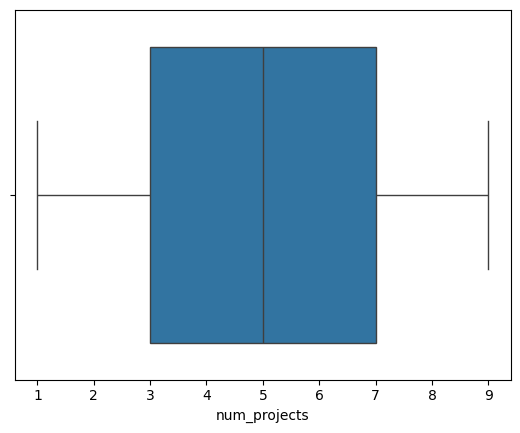

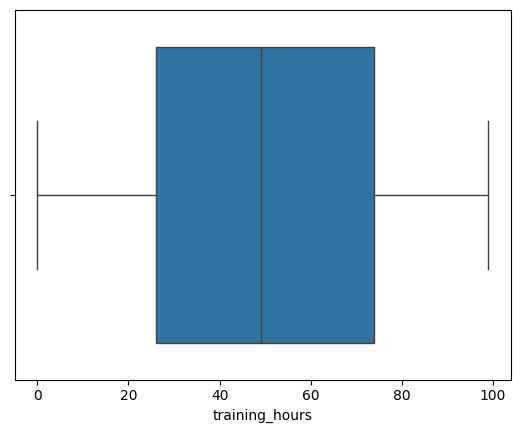

In [22]:
numeric_cols = [
    'age',
    'salary_usd',
    'years_experience',
    'satisfaction_score',
    'num_projects',
    'training_hours'
]

for col in numeric_cols:
    sns.boxplot(x=df[col])
    plt.show()

In [23]:
df["salary_usd"] = winsorize(
    df["salary_usd"],
    limits=[0.01, 0.01]
)

In [24]:
df["satisfaction_score"] = df["satisfaction_score"].replace(-1, np.nan)

imputer = SimpleImputer(strategy="median")

df["satisfaction_score"] = imputer.fit_transform(
    df[["satisfaction_score"]]
)

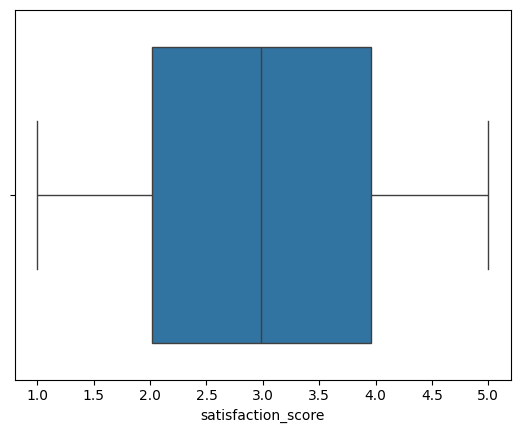

In [25]:
sns.boxplot(x=df['satisfaction_score'])
plt.show()

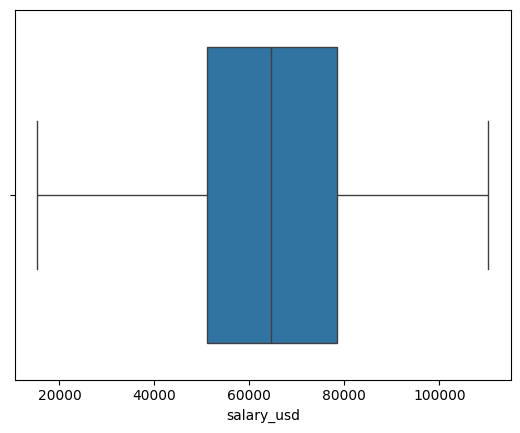

In [26]:
sns.boxplot(x=df['salary_usd'])
plt.show()

In [27]:
df['satisfaction_category'] = pd.cut(
    df['satisfaction_score'],
    bins=[0,2,3.5,5],
    labels=['Low','Medium','High']
)

In [28]:
ordinal_encoder = OrdinalEncoder(
    categories=[['Low','Medium','High']]
)

df['satisfaction_category'] = ordinal_encoder.fit_transform(df[['satisfaction_category']])

## Feature Scaling :

In [29]:
scale_cols = [ "age", "salary_usd", "years_experience", "satisfaction_score","num_projects","training_hours"]

scaler = StandardScaler()

df[scale_cols] = scaler.fit_transform(df[scale_cols])

In [30]:
df

,age,salary_usd,years_experience,satisfaction_score,performance_rating,num_projects,training_hours,education_level,attrition,gender_Male,gender_Non-binary,gender_Prefer not to say,department_finance,department_hr,department_marketing,department_sales,overtime_yes,remote_work_Hybrid,remote_work_On-site,satisfaction_category
0,-0.643912,-2.489470,-0.030128,0.311957,2.0,0.770181,-0.329705,3,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
1,1.476728,-0.525542,0.748492,0.197680,1.0,0.770181,0.161777,5,0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0
2,1.150476,-0.805773,0.229412,-0.980242,0.0,1.547448,-0.399916,1,0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,0.661097,-0.663846,1.354084,-1.463717,1.0,-1.172986,-0.610552,3,0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,0.824223,1.614128,-1.673879,-1.586784,3.0,1.158814,-1.628622,4,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5495,1.476728,-0.779894,0.229412,0.171309,2.0,0.381548,-0.224387,5,0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
5496,-0.807038,0.497867,-1.327826,0.224052,2.0,0.770181,1.355377,3,0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0
5497,1.476728,-0.439499,0.748492,1.059146,3.0,-0.784352,-0.435022,5,0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,2.0
5498,-1.296416,-1.134100,1.354084,0.382280,2.0,1.547448,0.863895,3,0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0


In [31]:
df["salary_per_experience"] = (
    df["salary_usd"] /
    (df["years_experience"] + 1)
)

df["workload_score"] = (
    df["num_projects"] *
    df["training_hours"]
)

df["productivity_score"] = (
    df["performance_rating"] *
    df["satisfaction_score"]
)

df

,age,salary_usd,years_experience,satisfaction_score,performance_rating,num_projects,training_hours,education_level,attrition,gender_Male,...,department_hr,department_marketing,department_sales,overtime_yes,remote_work_Hybrid,remote_work_On-site,satisfaction_category,salary_per_experience,workload_score,productivity_score
0,-0.643912,-2.489470,-0.030128,0.311957,2.0,0.770181,-0.329705,3,1,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,1.0,-2.566802,-0.253932,0.623913
1,1.476728,-0.525542,0.748492,0.197680,1.0,0.770181,0.161777,5,0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,1.0,-0.300569,0.124598,0.197680
2,1.150476,-0.805773,0.229412,-0.980242,0.0,1.547448,-0.399916,1,0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,-0.655413,-0.618850,-0.000000
3,0.661097,-0.663846,1.354084,-1.463717,1.0,-1.172986,-0.610552,3,0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,-0.281997,0.716168,-1.463717
4,0.824223,1.614128,-1.673879,-1.586784,3.0,1.158814,-1.628622,4,1,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,-2.395278,-1.887270,-4.760351
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5495,1.476728,-0.779894,0.229412,0.171309,2.0,0.381548,-0.224387,5,0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,1.0,-0.634363,-0.085614,0.342618
5496,-0.807038,0.497867,-1.327826,0.224052,2.0,0.770181,1.355377,3,0,0.0,...,0.0,0.0,1.0,1.0,1.0,0.0,1.0,-1.518691,1.043885,0.448104
5497,1.476728,-0.439499,0.748492,1.059146,3.0,-0.784352,-0.435022,5,0,0.0,...,0.0,0.0,0.0,1.0,1.0,0.0,2.0,-0.251359,0.341211,3.177438
5498,-1.296416,-1.134100,1.354084,0.382280,2.0,1.547448,0.863895,3,0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,1.0,-0.481758,1.336832,0.764560


In [32]:
Clean_dataset = df.copy()

Clean_dataset.head()

,age,salary_usd,years_experience,satisfaction_score,performance_rating,num_projects,training_hours,education_level,attrition,gender_Male,...,department_hr,department_marketing,department_sales,overtime_yes,remote_work_Hybrid,remote_work_On-site,satisfaction_category,salary_per_experience,workload_score,productivity_score
0,-0.643912,-2.489470,-0.030128,0.311957,2.0,0.770181,-0.329705,3,1,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,1.0,-2.566802,-0.253932,0.623913
1,1.476728,-0.525542,0.748492,0.197680,1.0,0.770181,0.161777,5,0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,1.0,-0.300569,0.124598,0.197680
2,1.150476,-0.805773,0.229412,-0.980242,0.0,1.547448,-0.399916,1,0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,-0.655413,-0.618850,-0.000000
3,0.661097,-0.663846,1.354084,-1.463717,1.0,-1.172986,-0.610552,3,0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,-0.281997,0.716168,-1.463717
4,0.824223,1.614128,-1.673879,-1.586784,3.0,1.158814,-1.628622,4,1,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,-2.395278,-1.887270,-4.760351
